<a href="https://www.kaggle.com/code/mohammednafayali/salary-prediction-regression-vs-nn-shap?scriptVersionId=343640505" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import warnings
warnings.filterwarnings('ignore')


/kaggle/input/datasets/wardabilal/salary-prediction-dataset/Salary_Data.csv


# 📈 Salary Prediction: Linear Regression vs. Deep Neural Network

## 1. Environment & Data Overview
This notebook evaluates salary predictions using both classical machine learning (`Scikit-Learn`) and deep learning (`TensorFlow/Keras`).

* **Dataset:** `Salary_Data.csv`
* **Target Variable:** `Salary` (Continuous numeric prediction)
* **Features:** `Age`, `Gender`, `Education Level`, `Job Title`, `Years of Experience`

In [40]:
df=pd.read_csv("/kaggle/input/datasets/wardabilal/salary-prediction-dataset/Salary_Data.csv")
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [41]:
print(f"The Null values are {df.isnull().sum()}")
print(88*"=")
print(f"The information about dataset:-\n{df.info()}")

The Null values are Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB
The information about dataset:-
None


## 2. Feature Preprocessing Pipeline

To handle missing values, numeric scaling, and categorical encoding without data leakage, we structure a `ColumnTransformer` with three sub-pipelines:

* **Numeric Pipeline (`Age`, `Years of Experience`):** Missing value imputation followed by `StandardScaler`.
* **Nominal Pipeline (`Gender`, `Job Title`):** Most-frequent imputation followed by `OneHotEncoder(handle_unknown='ignore')`.
* **Ordinal Pipeline (`Education Level`):** Most-frequent imputation followed by `OrdinalEncoder`.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [43]:
df=df.dropna(subset=["Salary"])
X=df.drop(columns="Salary")
y=df["Salary"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
pipe_mean=Pipeline(steps=[
    ("Mean Imputation",SimpleImputer()),
    ("Scaling", StandardScaler())
])

pipe_categorical = Pipeline(steps=[
    ('impute_text', SimpleImputer(strategy='most_frequent')),
    ('one_hot_encode', OneHotEncoder(handle_unknown='ignore'))
])

pipe_categorical_2= Pipeline(steps=[
    ('impute_text', SimpleImputer(strategy='most_frequent')),
    ('ordinal_encode', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

In [45]:
preprocessor=ColumnTransformer(transformers=[
    ("Mean",pipe_mean,["Age","Years of Experience"]),
    ("Ohe",pipe_categorical,["Gender","Job Title"]),
    ("LE",pipe_categorical_2,["Education Level"])
])

## 3. Baseline Model: Linear Regression Pipeline

We first train a standard Scikit-Learn `LinearRegression` model bundled inside an end-to-end `Pipeline` with our preprocessor.


In [46]:
model_pipeline=Pipeline(steps=[
    ("Steps",preprocessor),
    ("Model",LinearRegression())
])

In [47]:
model_pipeline.fit(X_train,y_train)
predictions=model_pipeline.predict(X_test)



mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("--- Final Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Prediction Accuracy Score: {r2:.2f}")


--- Final Evaluation Metrics ---
Mean Absolute Error (MAE): 15590.02
R² Prediction Accuracy Score: 0.84


## 5. Model Evaluation & Comparison
### Final Results Summary

| Model | MAE ($) | R² Score |
| :--- | :--- | :--- |
| **Linear Regression** | 15,590.02 | 0.84 |
| **TensorFlow Neural Network** | **7,793.91** | **0.95** |

### Key Takeaway
The Neural Network significantly outperforms Linear Regression, reducing the Mean Absolute Error by nearly **50%** and increasing variance explained ($R^2$) from **0.84 to 0.95**.

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# 1.Tansform features using preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

# 2.Build Sequential model using Input layer
nn_model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(256,activation="relu"),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

# 3.Compile
nn_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

# 4.Training modl
history = nn_model.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

# 5. Evaluate
tf_predictions = nn_model.predict(X_test_processed).flatten()

tf_mae = mean_absolute_error(y_test, tf_predictions)
tf_r2 = r2_score(y_test, tf_predictions)

print("--- TensorFlow Neural Network Metrics ---")
print(f"Mean Absolute Error (MAE): {tf_mae:.2f}")
print(f"R² Prediction Score: {tf_r2:.2f}")


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--- TensorFlow Neural Network Metrics ---
Mean Absolute Error (MAE): 7879.86
R² Prediction Score: 0.94


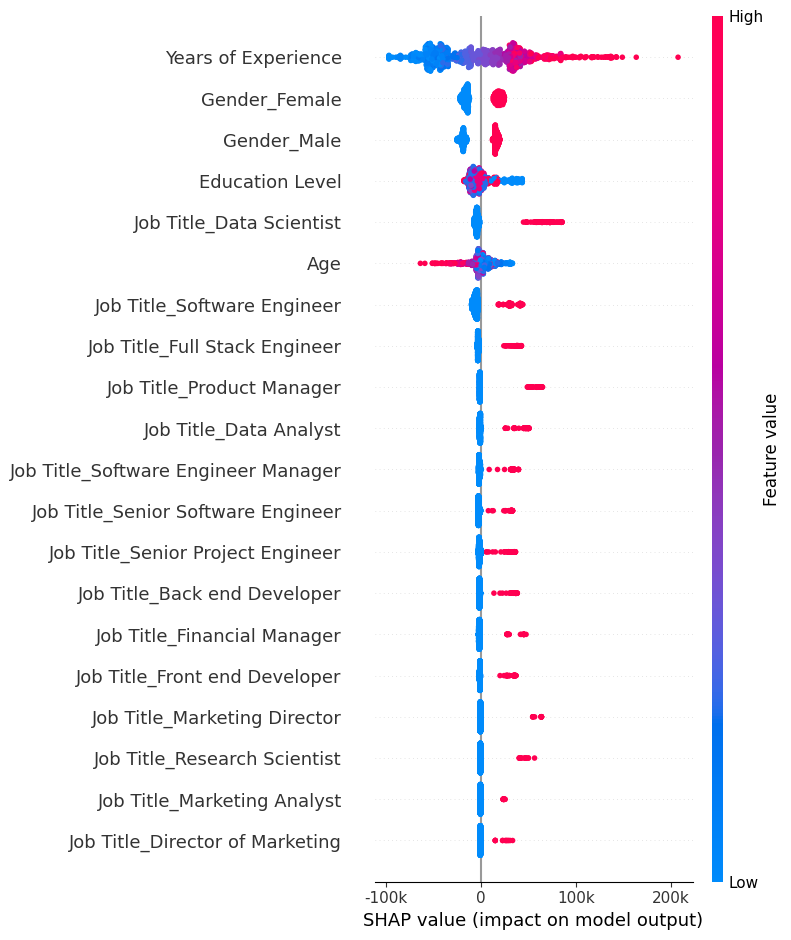

In [49]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Retrieve and clean feature names from preprocessor
raw_feature_names = preprocessor.get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in raw_feature_names]

# 2. Select background sample (100 random training instances)
np.random.seed(42)
background_indices = np.random.choice(X_train_processed.shape[0], 100, replace=False)
background = X_train_processed[background_indices]

# 3. DeepExplainer with additivity check disabled for Keras compatibility
explainer = shap.DeepExplainer(nn_model, background)
shap_vals = explainer.shap_values(X_test_processed, check_additivity=False)

# Handle output shape across SHAP versions for single-output regression
if isinstance(shap_vals, list):
    shap_matrix = shap_vals[0]
else:
    shap_matrix = shap_vals

if len(shap_matrix.shape) == 3:
    shap_matrix = shap_matrix.squeeze(-1)

# 4. Configure plot size & custom formatting for the x-axis
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_matrix, 
    X_test_processed, 
    feature_names=clean_feature_names,
    show=False
)

# Format x-axis numbers to 'k' notation (e.g. 50,000 -> 50k) to prevent overlap
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x != 0 else '0'))

plt.tight_layout()
plt.show()


# 🔍 Model Interpretability & SHAP Analysis

To open the "black box" of our deep learning model, we utilize **SHAP (SHapley Additive exPlanations)** based on game theory principles. This analysis breaks down how each individual feature pushes the predicted salary higher (positive SHAP value) or lower (negative SHAP value).

---

### 🔑 Key Interpretative Insights

* **Years of Experience (Primary Driver):**
  * `Years of Experience` is by far the most influential variable in predicting salary.
  * Higher values (represented by red dots) consistently exert extreme positive pressure, adding up to **+$200,000** to predicted salaries.
  * Low experience levels (blue dots) pull predicted salaries significantly downward (down to **-$80,000**).

* **High-Impact Career Roles:**
  * Specialized technical and managerial roles explicitly drive positive compensation adjustments.
  * Job titles such as `Data Scientist`, `Product Manager`, `Software Engineer`, and `Software Engineer Manager` consistently form distinct clusters strictly on the right side of zero (positive impact).

* **Demographics & Education Signals:**
  * `Age` shows a secondary localized effect—higher age aligns with positive value adjustments, though its impact magnitude is far smaller than total work experience.
  * `Education Level` demonstrates a moderate positive shift for higher degree levels, supporting standard professional progression metrics.

---

### 💡 Executive Summary
The deep learning model successfully captures intuitive real-world compensation structures: **work experience and specialized job roles serve as the primary drivers of salary scaling**, rather than background demographics alone.

In [50]:
import joblib
import json

# 1. Save preprocessor
joblib.dump(preprocessor, 'preprocessor.pkl')

# 2. Save ONLY model weights (avoids layer config deserialization errors)
nn_model.save_weights('salary_nn_weights.weights.h5')

# 3. Save feature metadata and input dimension
feature_info = {
    "input_dim": int(X_train_processed.shape[1]),
    "clean_feature_names": clean_feature_names,
    "unique_genders": list(df['Gender'].dropna().unique()),
    "unique_education": list(df['Education Level'].dropna().unique()),
    "unique_job_titles": sorted(list(df['Job Title'].dropna().unique())),
    "min_age": int(df['Age'].min()),
    "max_age": int(df['Age'].max()),
    "min_exp": float(df['Years of Experience'].min()),
    "max_exp": float(df['Years of Experience'].max())
}

with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f)

print("✅ Saved weights successfully:")
print(" - salary_nn_weights.weights.h5")
print(" - preprocessor.pkl")
print(" - feature_info.json")

✅ Saved weights successfully:
 - salary_nn_weights.weights.h5
 - preprocessor.pkl
 - feature_info.json
